<a href="https://colab.research.google.com/github/Liping-LZ/BDAO_DSDO/blob/main/Week%202/BDAO_Block3_Analysis_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BDAO Block 3 — Retail Data Analysis
### Festive & Co. · From Data to Business Insights

**How to use this notebook:**

| Symbol | Meaning |
|---|---|
| 📖 | Read before running |
| ▶️ | Just run this cell |
| ✏️ | Your turn |
| 🤖 | Use AI to help |
| 💬 | Discuss with your group |

**Structure:**
1. Setup + authenticate
2. Run the pipeline (skip if already done in Block 2)
3. Load data + create working DataFrames
4. Worked example — one complete analysis
5. Your analysis — explore freely using the patterns
6. Wrap up — top 3 insights


---
## ▶️ Step 1 — Install, authenticate and configure

In [ ]:
!pip install google-cloud-storage google-cloud-bigquery pandas-gbq ucimlrepo --quiet
print('Done.')

Done.


In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated.')

Authenticated.


In [ ]:
# ── FILL IN YOUR DETAILS ──────────────────────────────
project_id   = 'your-project-id'    # ← replace
bucket_name  = 'your-bucket-name'   # ← replace
dataset_name = 'your-dataset-name'  # ← replace
# ──────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from datetime import datetime
from google.cloud import storage, bigquery
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

storage_client  = storage.Client(project=project_id)
bigquery_client = bigquery.Client(project=project_id)

def run_query(sql):
    """Run SQL on BigQuery and return a DataFrame."""
    return bigquery_client.query(sql).to_dataframe()

def load_to_bq(df, table_name):
    """Save a DataFrame to BigQuery."""
    df_bq = df.copy()
    for col in df_bq.select_dtypes(include=['datetime64']).columns:
        df_bq[col] = df_bq[col].astype(str)
    df_bq.to_gbq(f'{dataset_name}.{table_name}',
                 project_id=project_id, if_exists='replace', progress_bar=False)
    print(f'  Saved: {project_id}.{dataset_name}.{table_name} ({len(df_bq):,} rows)')

print(f'Connected: {project_id}')

Connected: bdao-dsdo-458210


---
## ▶️ Step 2 — Run the pipeline

📖 **If you completed Block 2:** your data is already in BigQuery. Skip to Step 3.

📖 **If you did not complete Block 2:** run the cell below. It fetches the UCI retail data, cleans it, and loads it to BigQuery automatically. This is the full pipeline from Block 2 — same code, one function call.

⏱ Takes approximately 3-5 minutes to run.

In [ ]:
def run_pipeline():
    """
    Full ELT pipeline — UCI retail data to BigQuery.
    Same pipeline built in Block 2.
    Stages: Extract → Load raw to GCS → Validate → Transform → Load to BigQuery
    """
    t0 = datetime.now()
    print(f'Pipeline started: {t0.strftime("%H:%M:%S")}')
    print('=' * 50)

    # Stage 1: Extract
    print('[1/5] Extracting from UCI...')
    dataset = fetch_ucirepo(id=352)
    raw = pd.concat([dataset.data.ids, dataset.data.features], axis=1).copy()
    print(f'      {len(raw):,} rows fetched')

    # Stage 2: Load raw to GCS
    print('[2/5] Saving raw file to Cloud Storage...')
    bucket = storage_client.bucket(bucket_name)
    blob   = bucket.blob('online_retail_raw.json')
    blob.upload_from_string(raw.to_json(orient='records', lines=True))
    print(f'      gs://{bucket_name}/online_retail_raw.json')

    # Stage 3: Validate
    print('[3/5] Validating...')
    print(f'      Missing: {raw.isnull().sum().sum():,} | Dupes: {raw.duplicated().sum():,}')

    # Stage 4: Transform
    print('[4/5] Transforming...')
    df = raw.copy()
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    df['Quantity']    = pd.to_numeric(df['Quantity'],  errors='coerce')
    df['UnitPrice']   = pd.to_numeric(df['UnitPrice'], errors='coerce')
    df['InvoiceNo']   = df['InvoiceNo'].astype(str).str.strip()
    df['StockCode']   = df['StockCode'].astype(str).str.strip().str.upper()
    df['Description'] = df['Description'].astype(str).str.strip().str.title()
    df['Country']     = df['Country'].astype(str).str.strip().str.title()
    df['CustomerID']  = df['CustomerID'].astype(str).str.replace(r'\.0$','',regex=True)
    df = df.drop_duplicates().dropna(subset=['InvoiceDate'])
    df['is_cancellation'] = df['InvoiceNo'].str.startswith('C')
    df['is_return']       = df['Quantity'] < 0
    df['is_zero_price']   = df['UnitPrice'] <= 0
    df['is_guest']        = df['CustomerID'] == 'nan'
    df['Revenue']    = df['Quantity'] * df['UnitPrice']
    df['MonthLabel'] = df['InvoiceDate'].dt.strftime('%Y-%m')
    df['Year']       = df['InvoiceDate'].dt.year
    df['Month']      = df['InvoiceDate'].dt.month
    df['DayOfWeek']  = df['InvoiceDate'].dt.day_name()
    df['Hour']       = df['InvoiceDate'].dt.hour
    df = df[[
        'InvoiceNo','InvoiceDate','MonthLabel','Year','Month','DayOfWeek','Hour',
        'StockCode','Description','Quantity','UnitPrice','Revenue',
        'CustomerID','Country',
        'is_cancellation','is_return','is_zero_price','is_guest'
    ]]
    print(f'      {len(raw):,} → {len(df):,} rows')

    # Stage 5: Load to BigQuery
    print('[5/5] Loading to BigQuery...')
    dataset_ref = bigquery.DatasetReference(project_id, dataset_name)
    dataset_obj = bigquery.Dataset(dataset_ref)
    dataset_obj.location = 'EU'
    try:
        bigquery_client.get_dataset(dataset_ref)
    except Exception:
        bigquery_client.create_dataset(dataset_obj, timeout=30)
    load_to_bq(df, 'retail_transactions')

    secs = (datetime.now() - t0).seconds
    print('=' * 50)
    print(f'Pipeline complete in {secs}s')
    print(f'Table: {project_id}.{dataset_name}.retail_transactions')


# ── RUN OR SKIP ───────────────────────────────────────────────────────────
# If you already ran this in Block 2, skip this cell and go to Step 3
# If you need to run it now, uncomment the line below:

# run_pipeline()

---
## ▶️ Step 3 — Load data and create working DataFrames

📖 We load the full clean transactions table from BigQuery and split it into four focused DataFrames. Each one is filtered for a specific type of analysis so you do not have to repeat filters in every cell.

Run all cells in this step before starting your analysis.

In [ ]:
# Load the full clean transactions table from BigQuery
print('Loading retail_transactions from BigQuery...')

df = run_query(f"""
    SELECT *
    FROM `{project_id}.{dataset_name}.retail_transactions`
""")

# Parse date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print(f'Loaded: {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loading retail_transactions from BigQuery...
Loaded: 536,641 rows, 19 columns


,InvoiceNo,InvoiceDate,MonthLabel,Year,Month,DayOfWeek,Hour,...,CustomerID,Country,is_cancellation,is_guest,is_return,is_zero_price,negative_price
0,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
1,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
2,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
3,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
4,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False


In [ ]:
# ── WORKING DATAFRAMES ────────────────────────────────────────────────────

# df_sales — clean regular sales only
# Use for: revenue analysis, product analysis, country analysis, trends
df_sales = df[
    (~df['is_cancellation']) &
    (~df['is_return'])       &
    (~df['is_zero_price'])   &
    (df['Quantity'] > 0)
].copy()

# df_cancellations — cancelled orders only
# Use for: understanding cancellation patterns — when, where, which products
df_cancellations = df[df['is_cancellation']].copy()

# df_returns — returned items only
# Use for: understanding return patterns — which products, which countries
df_returns = df[df['is_return'] & ~df['is_cancellation']].copy()

# df_customers — clean sales from known customers only (no guest checkouts)
# Use for: customer-level analysis — loyalty, frequency, spend
df_customers = df_sales[~df_sales['is_guest']].copy()

print('Working DataFrames ready:')
print(f'  df_sales:          {len(df_sales):,} rows — clean regular sales')
print(f'  df_cancellations:  {len(df_cancellations):,} rows — cancelled orders')
print(f'  df_returns:        {len(df_returns):,} rows — returned items')
print(f'  df_customers:      {len(df_customers):,} rows — sales with known customer, guest checkouts excluded')

Working DataFrames ready:
  df_sales:          524,880 rows — clean regular sales
  df_cancellations:  9,251 rows — cancelled orders
  df_returns:        1,336 rows — returned items
  df_customers:      392,692 rows — sales with known customer, guest checkouts excluded


In [ ]:
# Quick overview of what we are working with
print('=== FESTIVE & CO. DATA OVERVIEW ===')
print(f'Period:           {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
print(f'Total orders:     {df_sales["InvoiceNo"].nunique():,}')
print(f'Known customers:  {df_customers["CustomerID"].nunique():,}')
print(f'Products:         {df_sales["StockCode"].nunique():,}')
print(f'Countries:        {df_sales["Country"].nunique()}')
print(f'Total revenue:    £{df_sales["Revenue"].sum():,.0f}')
print(f'Cancellation rate:{df_cancellations["InvoiceNo"].nunique()/df["InvoiceNo"].nunique()*100:.1f}%')
print()
df_sales.head(3)

=== FESTIVE & CO. DATA OVERVIEW ===
Period:           2010-12-01 to 2011-12-09
Total orders:     19,962
Known customers:  4,338
Products:         3,812
Countries:        38
Total revenue:    £10,619,987
Cancellation rate:14.8%



,InvoiceNo,InvoiceDate,MonthLabel,Year,Month,DayOfWeek,Hour,...,CustomerID,Country,is_cancellation,is_guest,is_return,is_zero_price,negative_price
0,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
1,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
2,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False


---
## 📖 Step 4 — Worked example

Before you start your own exploration, we will work through one complete analysis together to show how it works.

**Business question:** Is December really our strongest month — and if so, is it driven by more customers, more orders, or bigger baskets?

This connects to Sarah's concern: *'I do not know if what we experienced last January is normal or whether something we did drove customers away.'*

We need to understand the seasonal pattern before we can answer that.

In [ ]:
# Step 4.1 — Monthly revenue, orders and average order value
monthly = (
    df_sales
    .groupby('MonthLabel')
    .agg(
        orders          = ('InvoiceNo',  'nunique'),
        customers       = ('CustomerID', 'nunique'),
        total_revenue   = ('Revenue',    'sum'),
        avg_order_value = ('Revenue',    'mean')
    )
    .round(2)
    .reset_index()
)

print('Monthly summary:')
monthly

Monthly summary:


,MonthLabel,orders,customers,total_revenue,avg_order_value
0,2010-12,1559,886,821452.73,20.04
1,2011-01,1086,742,689811.61,20.25
2,2011-02,1100,759,522545.56,19.44
3,2011-03,1454,975,716215.26,20.18
4,2011-04,1246,857,536968.49,18.59
5,2011-05,1681,1057,769296.61,21.42
6,2011-06,1533,992,760547.01,21.29
7,2011-07,1475,950,718076.12,18.70
8,2011-08,1363,936,735717.26,21.47
9,2011-09,1837,1267,1056435.19,21.60


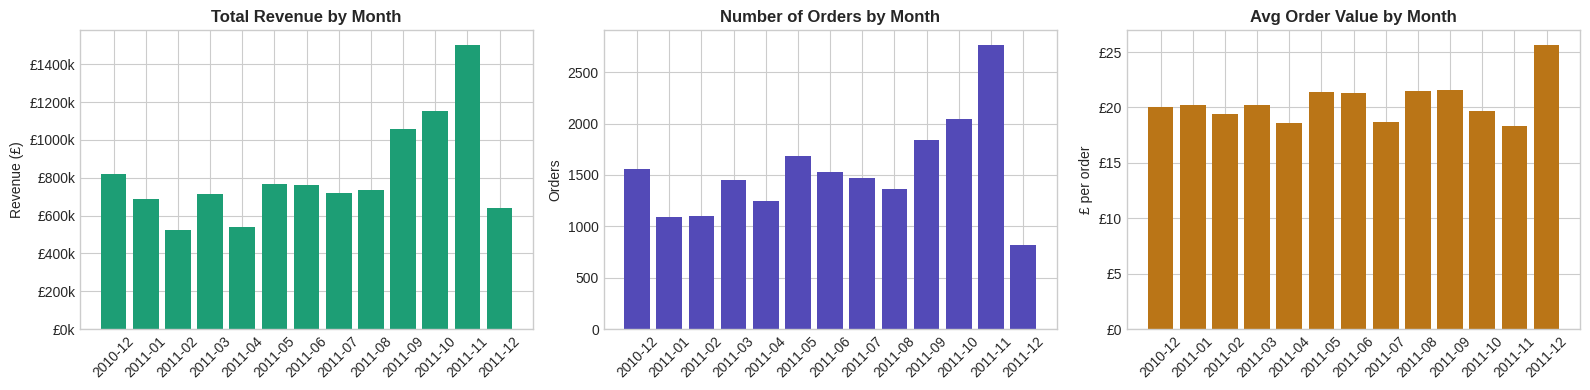

In [ ]:
# Step 4.2 — Visualise the pattern
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Revenue
axes[0].bar(monthly['MonthLabel'], monthly['total_revenue'], color='#1D9E75')
axes[0].set_title('Total Revenue by Month', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))

# Orders
axes[1].bar(monthly['MonthLabel'], monthly['orders'], color='#534AB7')
axes[1].set_title('Number of Orders by Month', fontweight='bold')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=45)

# Average order value
axes[2].bar(monthly['MonthLabel'], monthly['avg_order_value'], color='#BA7517')
axes[2].set_title('Avg Order Value by Month', fontweight='bold')
axes[2].set_ylabel('£ per order')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}'))

plt.tight_layout()
plt.show()

Quarterly summary:
  InvoiceDate  orders  customers  total_revenue  avg_order_value
0      2010Q4    1559        886      821452.73            20.04
1      2011Q1    3640       1777     1928572.43            20.00
2      2011Q2    4460       1992     2066812.11            20.56
3      2011Q3    4675       2162     2510228.57            20.65
4      2011Q4    5628       2561     3292920.84            19.91


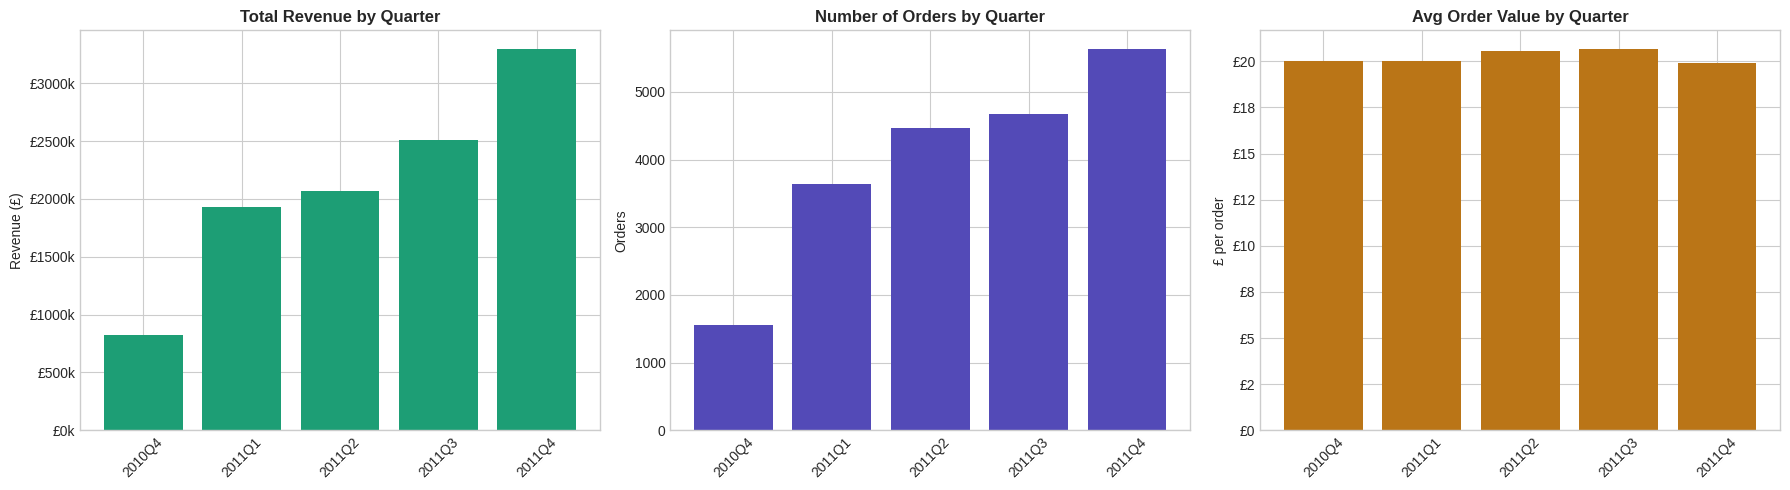

In [ ]:
# Step 4.3 - Plot revenue, orders, and average order value by quarter

# Aggregate data by quarter
quarterly = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.to_period('Q'))
    .agg(
        orders          = ('InvoiceNo',  'nunique'),
        customers       = ('CustomerID', 'nunique'),
        total_revenue   = ('Revenue',    'sum'),
        avg_order_value = ('Revenue',    'mean')
    )
    .round(2)
    .reset_index()
)
# Convert Quarter to string for plotting
quarterly['InvoiceDate'] = quarterly['InvoiceDate'].astype(str)

print('Quarterly summary:')
print(quarterly)

# Plotting the quarterly patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue
axes[0].bar(quarterly['InvoiceDate'], quarterly['total_revenue'], color='#1D9E75')
axes[0].set_title('Total Revenue by Quarter', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))

# Orders
axes[1].bar(quarterly['InvoiceDate'], quarterly['orders'], color='#534AB7')
axes[1].set_title('Number of Orders by Quarter', fontweight='bold')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=45)

# Average order value
axes[2].bar(quarterly['InvoiceDate'], quarterly['avg_order_value'], color='#BA7517')
axes[2].set_title('Avg Order Value by Quarter', fontweight='bold')
axes[2].set_ylabel('£ per order')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}'))

plt.tight_layout()
plt.show()

Daily summary for 2011:
          Day  orders  customers  total_revenue  avg_order_value
0  2011-01-04      36         35       16005.73            13.95
1  2011-01-05      55         46       32630.27            19.61
2  2011-01-06      50         46       40366.45            22.91
3  2011-01-07      53         46       28836.59            16.33
4  2011-01-09      48         48       15590.68            14.52


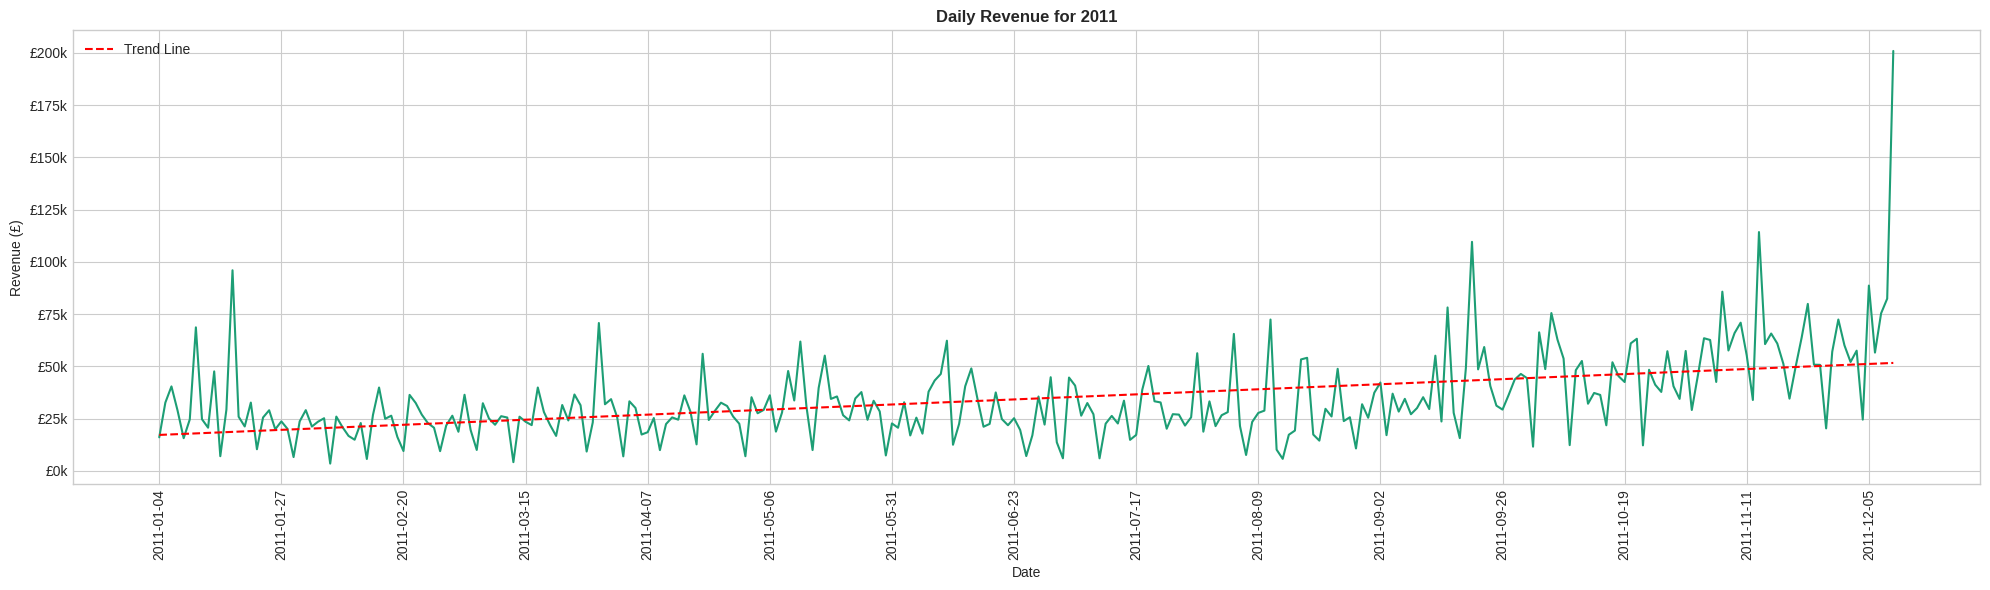

In [ ]:
# Step 4.4 - Plot the daily revenue
daily_2011 = (
    df_sales[
        (df_sales['InvoiceDate'] >= '2011-01-01') &
        (df_sales['InvoiceDate'] < '2012-01-01')
    ]
    .groupby(df_sales['InvoiceDate'].dt.date)
    .agg(
        orders          = ('InvoiceNo',  'nunique'),
        customers       = ('CustomerID', 'nunique'),
        total_revenue   = ('Revenue',    'sum'),
        avg_order_value = ('Revenue',    'mean')
    )
    .round(2)
    .reset_index()
)
daily_2011 = daily_2011.rename(columns={'InvoiceDate': 'Day'})

print('Daily summary for 2011:')
print(daily_2011.head())

fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(daily_2011['Day'].astype(str), daily_2011['total_revenue'], color='#1D9E75')
ax.set_title('Daily Revenue for 2011', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=90)
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))

# Add trend line
x_numeric = np.arange(len(daily_2011))
slope, intercept = np.polyfit(x_numeric, daily_2011['total_revenue'], 1)
trend_line = slope * x_numeric + intercept
ax.plot(daily_2011['Day'].astype(str), trend_line, color='red', linestyle='--', label='Trend Line')
ax.legend()

plt.tight_layout()
plt.show()

### **From data results to insights:**
#### **Finding**
Revenue and order volume follow a clear and consistent seasonal pattern. The monthly chart shows Q4 (October–November) generating the highest revenue of the year — November 2011 alone reaches £1.47 million, more than double the February low of £0.58 million. Crucially, the average order value remains almost flat across all months, hovering between £18–£26. The quarterly chart confirms the trend: each quarter outperforms the last, with 2011Q4 generating £3.3 million — four times the £0.8 million recorded in 2010Q4.

#### **What the data is telling us — and what it is not**
The growth in revenue is driven entirely by volume (more orders), not by customers spending more per transaction. Average order value is effectively flat across all quarters at around £20. This is an important distinction: the seasonal peak is a demand surge, not a behavioural change in how much individual customers spend when they do buy.

*Note also that 2010Q4 and December 2011 are incomplete months — 2010Q4 contains only December 2010, and December 2011 runs to only 9 December. The quarterly comparison should therefore be read with caution: 2011Q4 includes October, November, and the first 9 days of December. The true Q4 2011 figure would be significantly higher.

#### **Insight**
Festive & Co. is a genuinely seasonal business — not just slightly seasonal, but structurally dependent on Q4 demand. The flat average order value across seasons means the company cannot grow off-peak revenue by encouraging customers to spend more per visit. Customers who buy in February spend the same amount per order as customers who buy in November — they simply do not buy at all outside the gift-giving calendar. The revenue gap between peak and trough is a frequency problem, not a spend problem.

This also means the business carries significant risk. A poor Q4 — due to supply chain disruption, a failed Christmas campaign, or an economic downturn reducing discretionary spending — cannot be compensated for by the rest of the year. The revenue base is too concentrated.

#### **Recommendation**
To grow off-peak revenue, Festive & Co. needs to create reasons to buy that are independent of the existing holiday calendar — not rely on customers discovering one on their own.

Three specific actions follow from this analysis:

1. Build a themed event calendar for non-peak months. February already has Valentine's Day but the data shows it as the lowest month — suggesting Festive & Co. is not capturing that occasion effectively. Other opportunities: Mother's Day (March), Father's Day (June), back-to-school gifting (August/September). Each occasion needs a dedicated product bundle and a targeted email campaign, not just a generic promotion.
2. Launch a subscription or gifting programme. The flat average order value suggests customers buy what they need and stop — there is no upsell happening. A quarterly gift box subscription at a fixed price converts a one-time seasonal buyer into a predictable revenue stream. Even converting 5% of existing customers to a subscription would materially smooth the revenue curve.
3. Target corporate gifting for Q2 and Q3. Corporate clients buy gifts year-round — for employee recognition, client appreciation, and event gifting — and they tend to order in bulk, which would lift both order count and average order value simultaneously. The current customer base appears to be predominantly individual consumers. A B2B gifting proposition targeting SMEs would access demand that is not tied to the consumer holiday calendar at all.


---
Now it is your turn. Use the rest of this notebook to explore the questions you defined in the CNVO exercise.

---
## ✏️ Step 5 — Your analysis

Explore freely. Use the code patterns in Step 6 as a reference when you need them.

🤖 **Using AI for code — suggested prompt:**
```
I have a pandas DataFrame called df_sales with these columns:
InvoiceNo, InvoiceDate, MonthLabel, Year, Month, DayOfWeek, Hour,
StockCode, Description, Quantity, UnitPrice, Revenue,
CustomerID, Country, is_cancellation, is_return, is_guest

Write Python code to [describe what you want to find].
Show the result as a DataFrame and a bar chart.
```

💬 **As you go, keep asking your group:** what does this number mean for Sarah?
Every finding needs a 'so what' — not just a chart.

In [ ]:
# Your analysis — cell 1
# Business question:
#



In [ ]:
# Your analysis — cell 2
# Business question:
#



In [ ]:
# Your analysis — cell 3
# Business question:
#



In [ ]:
# Your analysis — cell 4
# Business question:
#



In [ ]:
# Your analysis — cell 5
# Business question:
#



In [ ]:
# Your analysis — cell 6
# Business question:
#



---
## 📖 Step 6 — Code patterns reference

Use these as templates. Copy and adapt — change column names for your question.

> These are tools, not a to-do list. Use what is relevant to your questions.

In [ ]:
# PATTERN 1 — Group by a column and summarise
# Change 'Country' to any column you want to group by
(
    df_sales
    .groupby('Country')
    .agg(
        total_revenue = ('Revenue',    'sum'),
        order_count   = ('InvoiceNo',  'nunique'),
        avg_order     = ('Revenue',    'mean'),
        customers     = ('CustomerID', 'nunique')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
    .head(10)
)

In [ ]:
# PATTERN 2 — Filter rows then analyse
# Example: non-UK countries with more than 50 orders
(
    df_sales[
        (df_sales['Country'] != 'United Kingdom') &
        (df_sales['Revenue'] > 0)
    ]
    .groupby('Country')
    .agg(total_revenue=('Revenue','sum'), orders=('InvoiceNo','nunique'))
    .query('orders > 50')
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

In [ ]:
# PATTERN 3 — Calculate percentage share and cumulative %
# Useful for: 80/20 analysis, revenue concentration
by_product = (
    df_sales
    .groupby(['StockCode','Description'])
    .agg(revenue=('Revenue','sum'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)
by_product['pct']        = (by_product['revenue'] / by_product['revenue'].sum() * 100).round(2)
by_product['cumulative'] = by_product['pct'].cumsum().round(2)

# How many products make up 80% of revenue?
top80 = by_product[by_product['cumulative'] <= 80]
print(f'{len(top80):,} products = 80% of revenue ({len(top80)/len(by_product)*100:.1f}% of catalogue)')
by_product.head(10)

In [ ]:
# PATTERN 4 — Customer-level summary
customer_summary = (
    df_customers
    .groupby('CustomerID')
    .agg(
        country         = ('Country',     'first'),
        total_orders    = ('InvoiceNo',   'nunique'),
        total_spend     = ('Revenue',     'sum'),
        avg_order_value = ('Revenue',     'mean'),
        first_purchase  = ('InvoiceDate', 'min'),
        last_purchase   = ('InvoiceDate', 'max')
    )
    .round(2)
    .reset_index()
    .sort_values('total_spend', ascending=False)
)
print(f'Unique customers: {len(customer_summary):,}')
customer_summary.head(10)

In [ ]:
# PATTERN 5 — Bar chart
# Replace x_data, y_data, title, labels with your own values

fig, ax = plt.subplots(figsize=(10, 5))

x_data = ['A','B','C']          # ← your x values
y_data = [100, 200, 150]        # ← your y values
title  = 'My Chart Title'       # ← your title
xlabel = 'Category'             # ← x axis label
ylabel = 'Revenue (£)'          # ← y axis label

ax.bar(x_data, y_data, color='#1D9E75')
ax.set_title(title, fontweight='bold', fontsize=13)
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
# PATTERN 6 — Compare two groups
# Example: repeat customers vs one-time buyers

# Count orders per customer
order_counts = df_customers.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
order_counts.columns = ['CustomerID','order_count']

# Classify
order_counts['type'] = order_counts['order_count'].apply(
    lambda x: 'One-time' if x == 1 else 'Repeat'
)

# Merge back to get revenue
customer_rev = df_customers.groupby('CustomerID')['Revenue'].sum().reset_index()
merged = order_counts.merge(customer_rev, on='CustomerID')

# Compare
comparison = (
    merged.groupby('type')
    .agg(customers=('CustomerID','count'), total_revenue=('Revenue','sum'), avg_spend=('Revenue','mean'))
    .round(2)
    .reset_index()
)
comparison['revenue_share_%'] = (comparison['total_revenue'] / comparison['total_revenue'].sum() * 100).round(1)
comparison

In [ ]:
# PATTERN 7 — Cancellation rate by group
# Example: cancellation rate by country

cancel_rate = (
    df
    .groupby('Country')
    .agg(
        total_orders   = ('InvoiceNo', 'nunique'),
        cancellations  = ('is_cancellation', 'sum')
    )
    .reset_index()
)
cancel_rate['cancel_rate_%'] = (
    cancel_rate['cancellations'] / cancel_rate['total_orders'] * 100
).round(1)

cancel_rate.query('total_orders > 50').sort_values('cancel_rate_%', ascending=False).head(10)

In [ ]:
# OPTIONAL: SQL via BigQuery if you prefer
# 🤖 Prompt: 'Write a BigQuery SQL query that reads from
# `project_id.dataset_name.retail_transactions` and [describe what you want].
# Exclude cancellations (is_cancellation = FALSE) and returns (is_return = FALSE).'

# sql_result = run_query(f"""
#     SELECT ...
#     FROM `{project_id}.{dataset_name}.retail_transactions`
#     WHERE is_cancellation = FALSE
#       AND is_return = FALSE
# """)
# sql_result

---
## ✏️ Step 7 — Wrap up: your top 3 insights

Your instructor will ask you to stop exploring and present back shortly.

Before you present, complete this for your **top 3 findings**.


**Finding** --> **Insight**  --> **Recommendation**

### Insight 1

**Finding:** *(what the data shows — include specific numbers)*

**Insight:** *(what this means for Festive & Co.)*

**Recommendation:** *(what Sarah should do — be specific)*

---

### Insight 2

**Finding:**

**Insight:**

**Recommendation:**

---

### Insight 3

**Finding:**

**Insight:**

**Recommendation:**